In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

from math import ceil
from scipy import ndimage
from math import sqrt



# Question 1

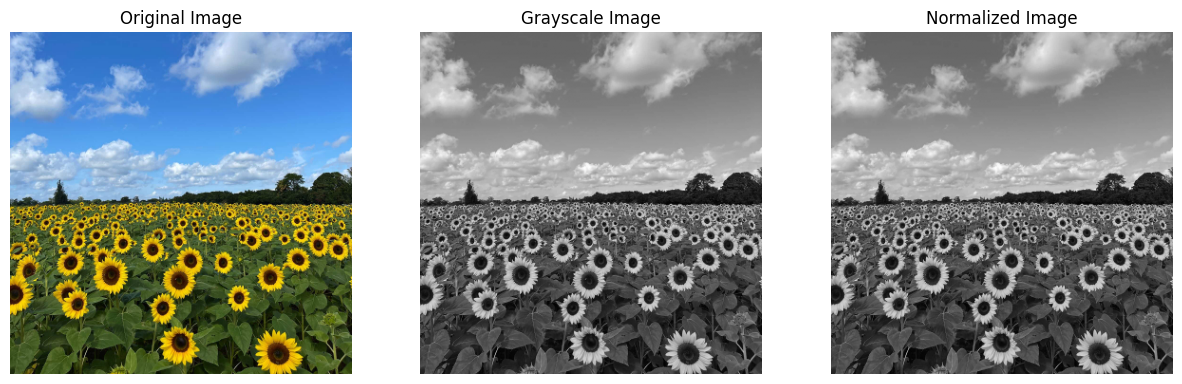

In [2]:
# Read the image at reduced resolution
sunflower_img = cv.imread('images/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
gray_img = cv.cvtColor(sunflower_img, cv.COLOR_BGR2GRAY)
normalized_img = gray_img.astype(np.float32) / 255.0  # normalize image to [0,1]

# display 3 images
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(sunflower_img, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(normalized_img, cmap='gray')
plt.title('Normalized Image')
plt.axis('off')

plt.show()


Creating laplacian of gaussian

$$\text{LoG}(x, y) = -\frac{1}{\pi\sigma^4}\left[1 - \frac{x^2 + y^2}{2\sigma^2}\right]e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

In [3]:
def LoG_kernal(sigma, debug=False):
    half_width = int(ceil(3*sigma))
    width = 2*half_width + 1

    y, x = np.mgrid[-half_width:half_width+1, -half_width:half_width+1]

    r_2 = x**2 + y**2
    # Laplacian of Gaussian formula
    LoG = -1/(np.pi * sigma**4) * (1 - r_2/(2*sigma**2)) * np.exp(-r_2/(2*sigma**2))

    # making the sum of kernel elements zero
    LoG -= LoG.mean()

    if debug:
        print(f"Kernel size: {width}x{width}")
        print(f"Sum of kernel elements: {LoG.sum()}")
        # 3D plot
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(x, y, LoG, cmap='viridis', edgecolor='k', alpha=0.8)
        ax.set_title(f"LoG Kernel (σ={sigma})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("LoG value")
        plt.show()

    return LoG

In [4]:
initial_sigma = 2.0
k = 1.2
n_levels = 12
sigmas = [initial_sigma * (k**i) for i in range(n_levels)]
print("Scale levels (σ):", sigmas)

Scale levels (σ): [2.0, 2.4, 2.88, 3.4559999999999995, 4.1472, 4.976639999999999, 5.971967999999999, 7.166361599999998, 8.599633919999997, 10.319560703999997, 12.383472844799995, 14.860167413759994]


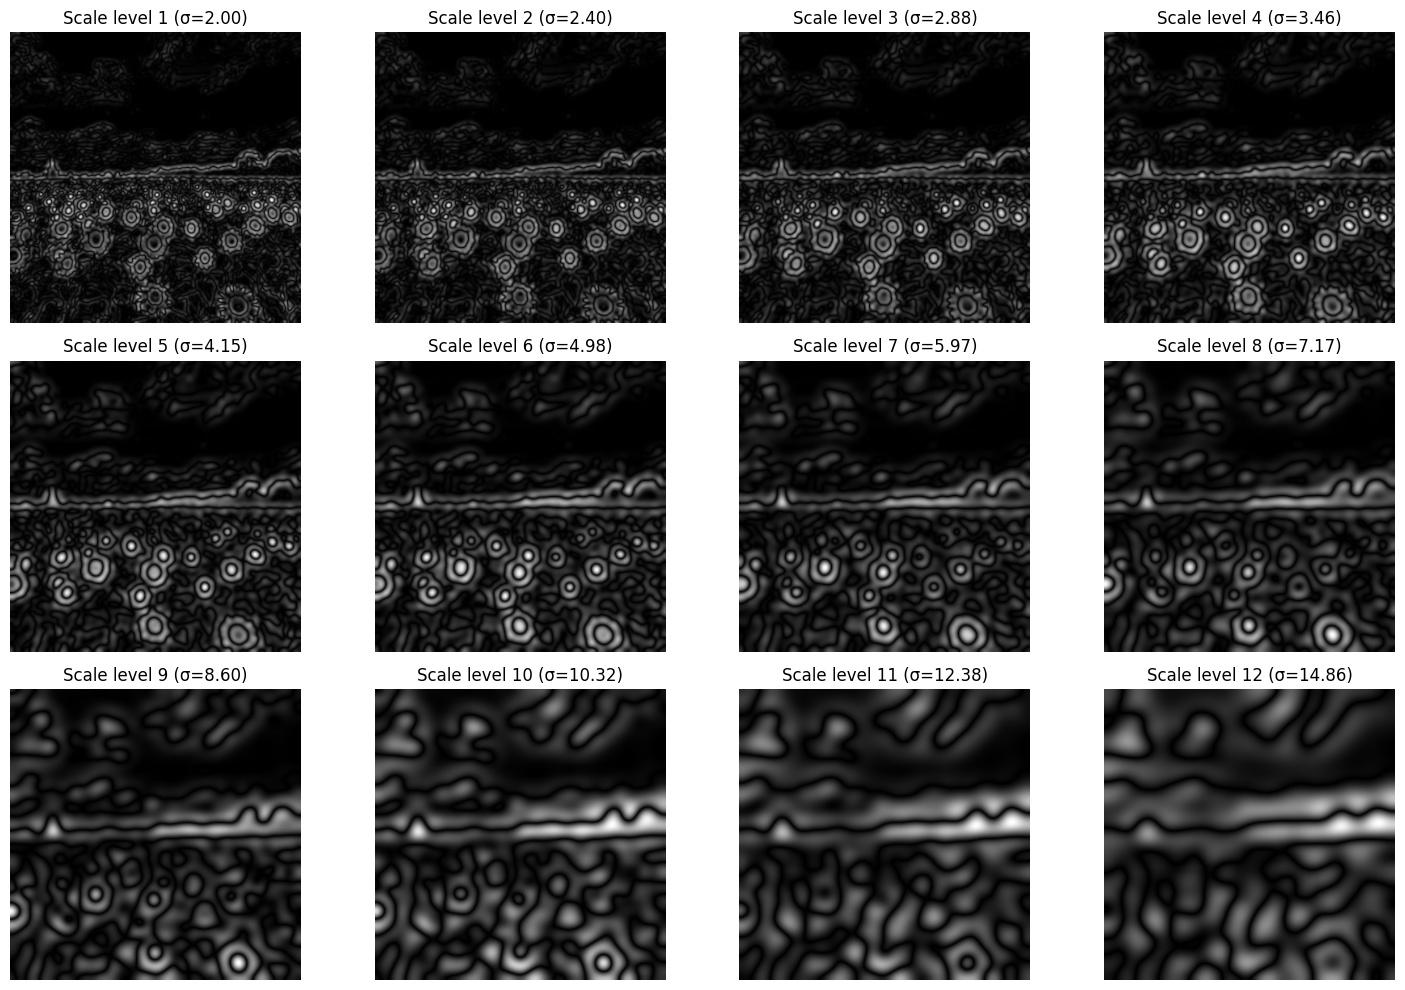

In [5]:
height, width = normalized_img.shape
scale_space = np.zeros((height, width, n_levels), dtype=np.float32)

for i, sigma in enumerate(sigmas):
    LoG = LoG_kernal(sigma)
    filtered_img = cv.filter2D(normalized_img, -1, LoG)
    # Scale-normalized LoG response of the squared laplacian response
    scale_space[:, :, i] = (sigma**2) * np.abs(filtered_img)

# Visualize some scale levels
n_display = 12
plt.figure(figsize=(15, 10))
for i in range(n_display):
    plt.subplot(3, 4, i+1)
    plt.imshow(scale_space[:, :, i*(n_levels//n_display)], cmap='gray')
    plt.title(f'Scale level {i*(n_levels//n_display)+1} (σ={sigmas[i*(n_levels//n_display)]:.2f})')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
def nonmax2d(response, neighborhood=3):
    """Return boolean mask of pixels that are local maxima in a neighborhood."""
    if neighborhood % 2 == 0:
        neighborhood += 1
    footprint = np.ones((neighborhood, neighborhood), dtype=bool)
    local_max = ndimage.maximum_filter(response, footprint=footprint, mode='reflect')
    mask = (response == local_max)
    return mask

nms2d_masks = np.zeros_like(scale_space, dtype=bool)
for i in range(n_levels):
    nms2d_masks[:, :, i] = nonmax2d(scale_space[:, :, i], neighborhood=3)


In [7]:
candidates = []
for i in range(n_levels):
    resp = scale_space[:, :, i]
    mask2d = nms2d_masks[:, :, i]
    if i == 0:
        is_scale_max = (resp >= scale_space[:, :, i+1])
    elif i == n_levels - 1:
        is_scale_max = (resp >= scale_space[:, :, i-1])
    else:
        is_scale_max = (resp >= scale_space[:, :, i-1]) & (resp >= scale_space[:, :, i+1])

    final_mask = mask2d & is_scale_max
    ys, xs = np.nonzero(final_mask)
    for y, x in zip(ys, xs):
        candidates.append((y, x, i, float(resp[y, x])))


In [8]:
threshold = 0.31   # tune per dataset; lower => more blobs
max_blobs = 1000

# filter by threshold and convert scale index to sigma
blobs = []
for (y, x, scale_idx, resp_val) in candidates:
    if resp_val >= threshold:
        sigma = sigmas[scale_idx]
        blobs.append((y, x, sigma, resp_val))

# sort and keep top
blobs.sort(key=lambda b: b[3], reverse=True)
blobs = blobs[:max_blobs]


In [9]:
def sigma_to_radius(sigma):
    return int(round(sqrt(2) * sigma))

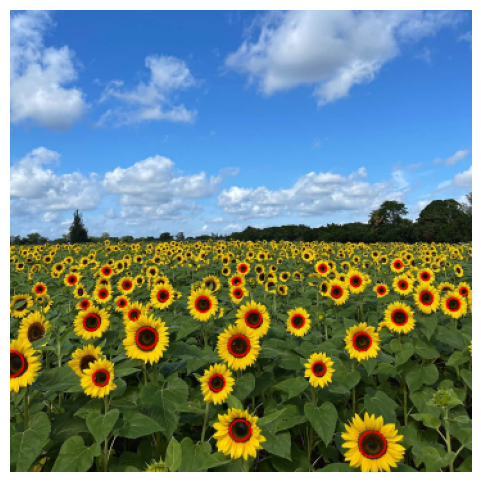

In [10]:
def draw_blobs(img_bgr, blobs, radius_factor=sqrt(2), color=(0,0,255)):
    out = img_bgr.copy()
    for (y, x, sigma, resp) in blobs:
        r = int(round(radius_factor * sigma))
        cv.circle(out, (int(x), int(y)), r, color, 1, lineType=cv.LINE_AA)
    return out

# Example
out = draw_blobs(sunflower_img, blobs[:200])  # draw top 200

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB))
plt.axis('off')  # Hide axes
plt.show()



In [11]:
blob_params = []
for (y, x, sigma, resp) in blobs:
    radius = sigma_to_radius(sigma)
    blob_params.append((x, y, radius, resp))

# Sort by radius (largest first)
blob_params.sort(key=lambda b: b[2], reverse=True)

# Get top N largest circles
N = min(10, len(blob_params))  # report top 10
print(f"\nTop {N} Largest Detected Circles:")
print("Index\tX\tY\tRadius\tResponse")
for i in range(N):
    x, y, r, resp = blob_params[i]
    print(f"{i+1}\t{x:.2f}\t{y:.2f}\t{r:.2f}\t{resp:.4f}")


Top 10 Largest Detected Circles:
Index	X	Y	Radius	Response
1	282.00	338.00	10.00	0.3537
2	0.00	275.00	10.00	0.3503
3	106.00	255.00	8.00	0.3709
4	178.00	261.00	8.00	0.3529
5	179.00	327.00	8.00	0.3499
6	274.00	258.00	7.00	0.3443
7	303.00	239.00	6.00	0.3822
8	161.00	290.00	6.00	0.3677
9	150.00	229.00	6.00	0.3673
10	189.00	240.00	6.00	0.3593
